In [1]:
using CairoMakie
using FourierFlows
using JLD2
using Printf
using StatsBase
include("../AnalysisUtils.jl")

mapfilter_snapshots (generic function with 1 method)

In [2]:
function compute_GBM_parameters(directory, idx)
    _, _, k0, _ = load_snapshot(directory, 1)
    t0, _, _, _ = load_snapshot(directory, 2)

    t, _, k, _ = load_snapshot(directory, idx)
    
    Δt = t - t0
    mask = isfinite.(k[:,1]) .& isfinite.(k[:,2])
    K0 = mean(sqrt.(k0[mask,1].^2 + k0[mask,2].^2))
    K = sqrt.(k[mask,1].^2 + k[mask,2].^2)
    mean_K = mean(K)
    var_K = var(K)
        
    drift = (log(mean_K/K0)/(Δt))
    diffusion = (log(var_K/(K0^2 * exp(2*drift.*Δt)) .+ 1) ./ (Δt))
    return drift, diffusion
end

compute_GBM_parameters (generic function with 1 method)

In [3]:
#predicate = "/scratch/nad9961/swqg/"
predicate = "/scratch/nad9961/twolayer_rays/"
froude_number = []
drift = []
diffusion = []
for line=readlines("raytracing-runs-two-layer.txt")
    run_directory = predicate * line
    println(run_directory)
    f0, Cg = read_parameters(run_directory)
    nx, Lx = get_grid_size(run_directory, "2Lqg")
    grid = TwoDGrid(;nx, Lx)
    Nsnapshots = floor(Int, count_snapshots(run_directory))
    Nqg_snapshots = count_key_snapshots(run_directory, "2Lqg")

    _, qh = load_key_snapshot(run_directory, "2Lqg", Nqg_snapshots)
    params = read_2Lqg_params(run_directory, "2Lqg")
    
    qch = 0.5 * (qh[:,:,1] - qh[:,:,2])
    ψch = -qch ./ (grid.Krsq .+ 2*params.F)
    uch = -1im * grid.l  .* ψch
    vch =  1im * grid.kr .* ψch
    
    u = irfft(uch, grid.nx)
    v = irfft(vch, grid.nx)
    rms_u = sqrt.(sum(u.^2 + v.^2)/grid.nx/grid.ny)
    
    for idx = Nsnapshots:Nsnapshots
        μ, σ2 = compute_GBM_parameters(run_directory, idx)
        push!(drift, μ)
        push!(diffusion, sqrt(σ2)) 
        push!(froude_number, rms_u / Cg)
    end
        
end

/scratch/nad9961/twolayer_rays/1542998/8
/scratch/nad9961/twolayer_rays/1542998/9
/scratch/nad9961/twolayer_rays/1542998/10
/scratch/nad9961/twolayer_rays/1554309/1
/scratch/nad9961/twolayer_rays/1554309/2
/scratch/nad9961/twolayer_rays/1554309/3
/scratch/nad9961/twolayer_rays/1554309/4
/scratch/nad9961/twolayer_rays/1554309/5
/scratch/nad9961/twolayer_rays/1554309/6
/scratch/nad9961/twolayer_rays/1554309/7


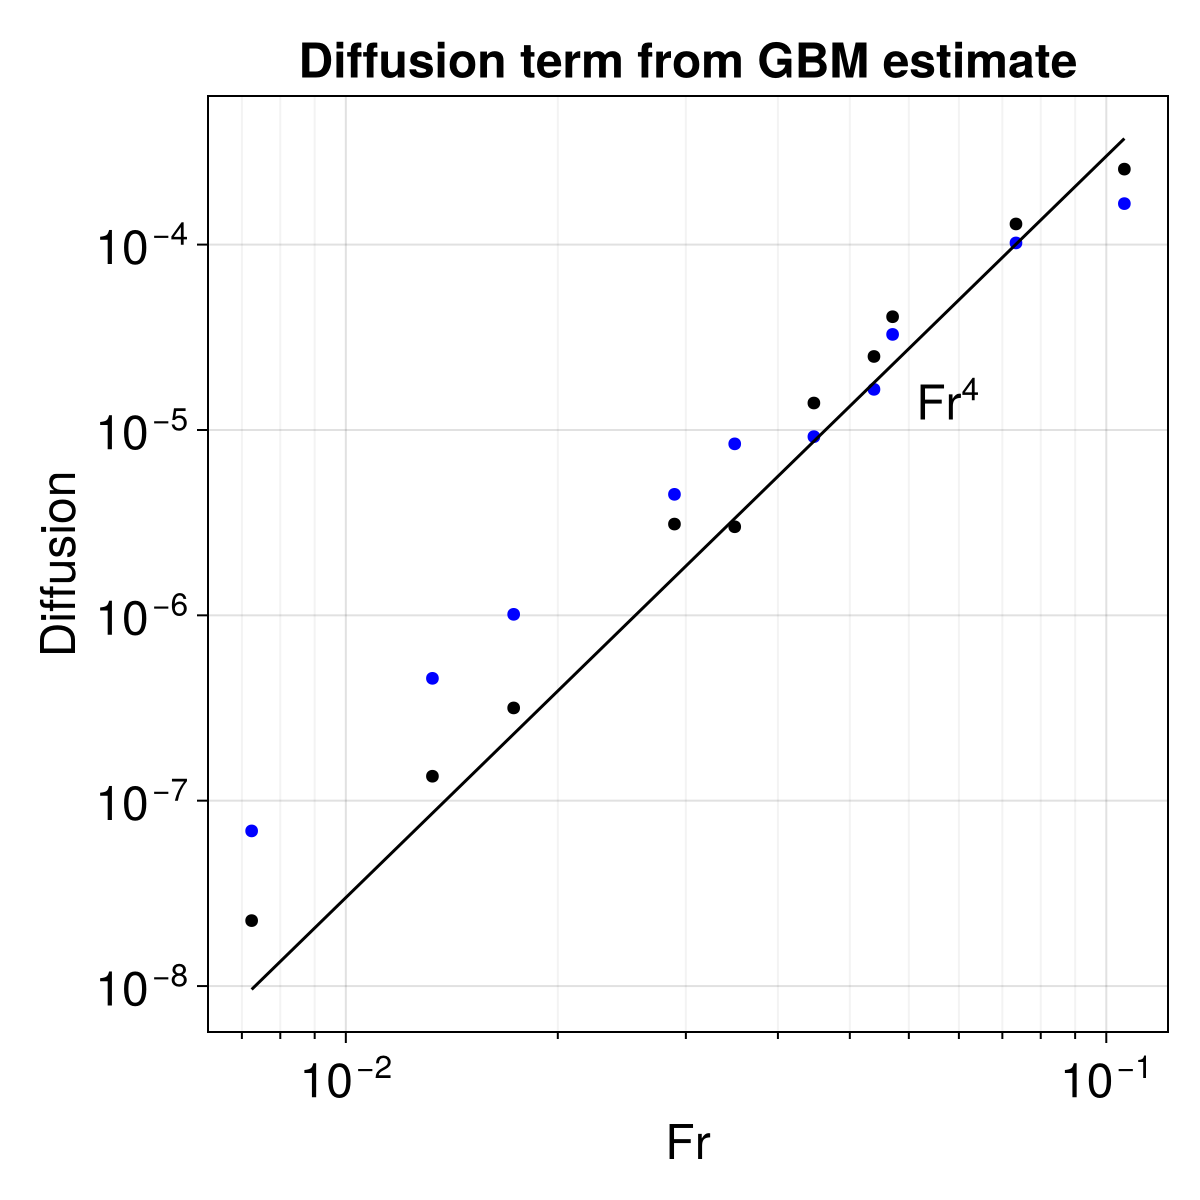

In [4]:
fig = Figure(size=(600, 600), fontsize=24)
ax = Axis(fig[1,1]; xscale=log10, yscale=log10, xlabel="Fr", ylabel=rich("Diffusion"), title="Diffusion term from GBM estimate",
    xticks=LogTicks(WilkinsonTicks(2; k_max=2)),
    xminorticksvisible=true,
    xminorgridvisible=true,
    xminorticks=IntervalsBetween(10)) #title=rich("Median frequency vs Fr", subscript("rms")))
scatter!(ax, froude_number, drift/3, color=:black)
scatter!(ax, froude_number, diffusion.^2/2, color=:blue)
lines!(ax, froude_number, 3*froude_number.^4, linestyle=:solid, color=:black)
text!(ax, 10^(-1.25), 1e-5; text=rich("Fr", superscript("4")))
#scatter!(ax, froude_number, ωs./f0s, markersize=12, color=:red)

#save("images/froude_number_vs_median_freq.eps", fig)
fig

In [5]:
run_directory = "/scratch/nad9961/rsw_plots/1925846/"
Nruns = 11
bs = zeros(Nruns)
u_rmss = zeros(Nruns)
for i=1:Nruns
    file = jldopen(@sprintf("%s/%d/twoL-%d.jld2", run_directory, i, i))
    println(file["b"])
    bs[i] = file["b"]
    u_rmss[i] = file["Fr"]
    close(file)
end

2.31880378842734e-9
3.0539493994044344e-8
6.426758884969314e-8
6.121860773880981e-7
3.6137260924395195e-6
9.333367871149352e-6
8.190047066016768e-6
5.747836580903494e-9
9.179523901333156e-9
3.274445059277139e-7
4.020201636824455e-6


In [6]:
using LsqFit

x_data = vcat(u_rmss, froude_number, froude_number)
y_data = vcat(100/9 * bs / 3, drift/3 / 3,  diffusion.^2/2 / 3)

filter = 1e-2 .< x_data .< 0.1
x_data = x_data[filter]
y_data = y_data[filter]

m(k, p) = p[1]*k .+ p[2]
p0 = [4.0, 1.0]
fit = curve_fit(m, log.(x_data), log.(y_data), p0)
println(fit.param)

[3.618309691377098, -0.9914839915024701]


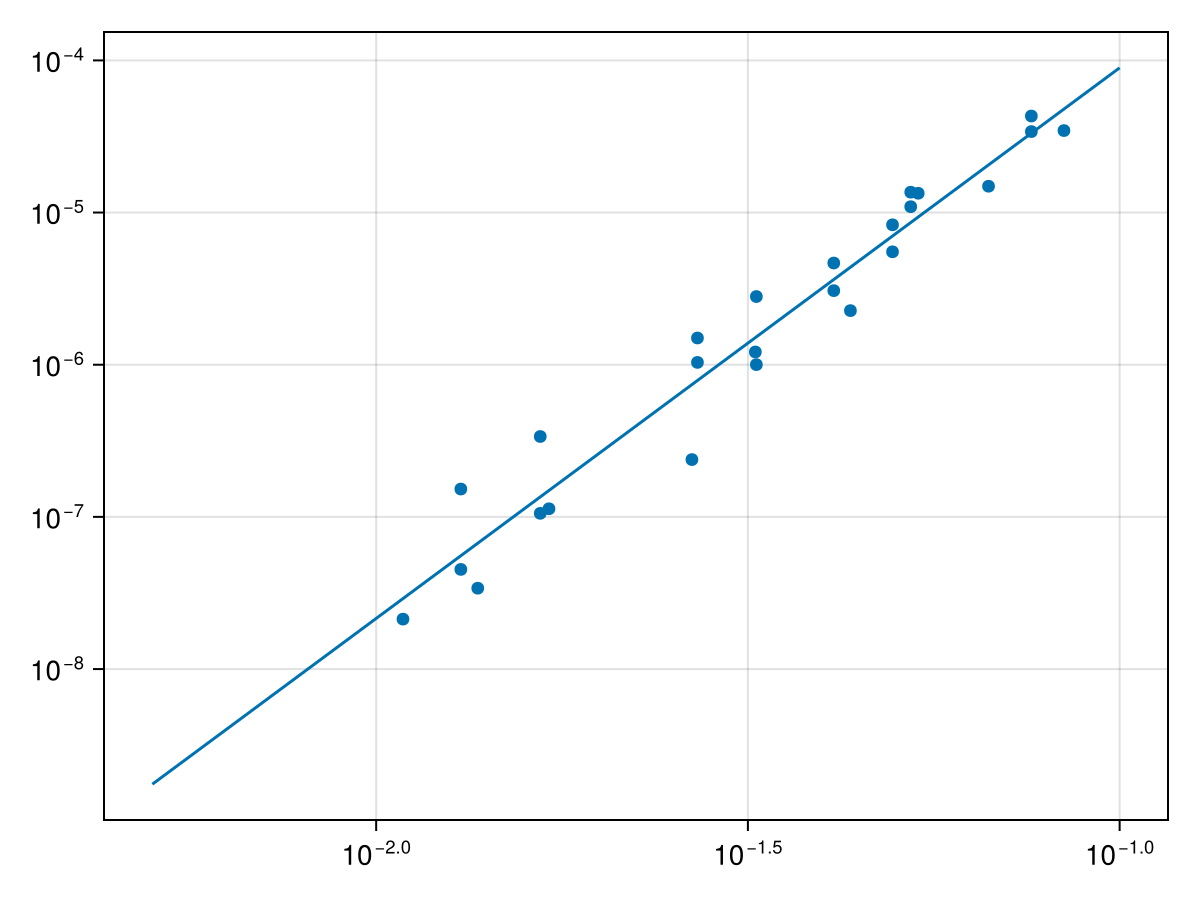

In [7]:
test_f = Figure()
ax = Axis(test_f[1,1]; xscale=log10, yscale=log10)
x_range = 0.005:0.001:0.1
scatter!(ax, x_data, y_data)
lines!(ax, x_range, exp.(fit.param[2])*x_range.^(fit.param[1]))

test_f

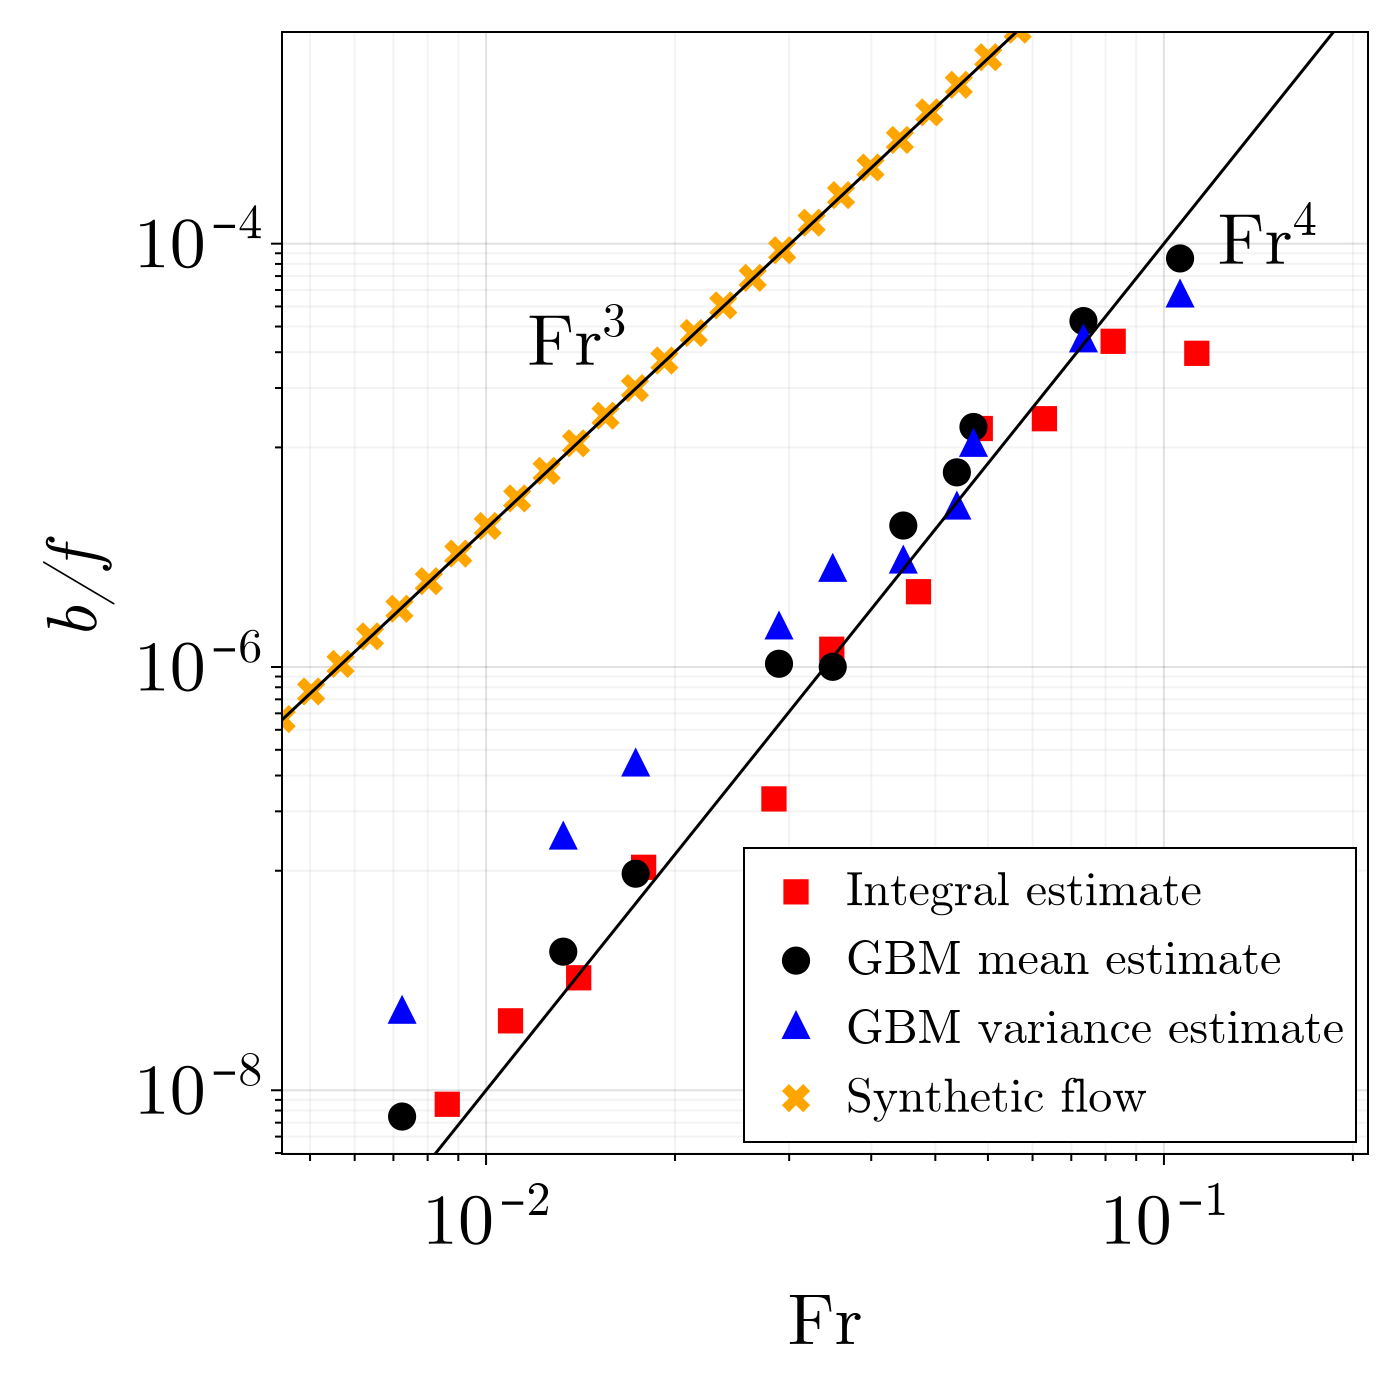

In [38]:
fig = Figure(fonts = (; regular = "/home/nad9961/cmu-font/cmunrm.ttf", bold="/home/nad9961/cmu-font/cmunbx.ttf", math="/home/nad9961/cmu-font/cmunci.ttf"), 
    size=(700, 700), fontsize=36)
ax = Axis(fig[1,1]; xscale=log10, yscale=log10, xlabel="Fr", ylabel=rich("b/f", font=:math),
    xticks=LogTicks(WilkinsonTicks(2; k_max=2)),
    limits=((5e-3, 2e-1), (5e-9, 1e-3)),
    yminorticksvisible=true,
    yminorgridvisible=true,
    yminorticks=IntervalsBetween(10),
    xminorticksvisible=true,
    xminorgridvisible=true,
    xminorticks=IntervalsBetween(10)) #title=rich("Median frequency vs Fr", subscript("rms")))
scatter!(u_rmss, 100/9 * bs / 3, color=:red, marker=:rect, label="Integral estimate", markersize=20)
scatter!(ax, froude_number, drift/3 / 3, color=:black, label="GBM mean estimate", markersize=20)
scatter!(ax, froude_number, diffusion.^2/2 / 3, color=:blue, marker=:utriangle, label="GBM variance estimate", markersize=20)

u_rms_range = 0.002:0.002:0.2
lines!(ax, u_rms_range, u_rms_range.^4, linestyle=:solid, color=:black)
scatter!(ax, U0/3, 100 / 9 * synthetic_bs / 3, color=:orange, marker=:xcross, label="Synthetic flow", markersize=20)
lines!(ax, u_rms_range, 4.5*u_rms_range.^3, linestyle=:solid, color=:black)
text!(ax, 1.15e-2, 2e-5; text=rich("Fr", superscript("3")))
#lines!(ax, u_rms_range, exp.(fit.param[2])*u_rms_range.^(fit.param[1]), linestyle=:dash, color=:black, label=rich(@sprintf("Best fit: %0.2f(Fr)", exp.(fit.param[2])), superscript(@sprintf("%0.1f", fit.param[1]))))
text!(ax, 1.2e-1, 6e-5; text=rich("Fr", superscript("4")))
axislegend(ax, position=:rb, labelsize=24, patchsize=(40, 30))
#scatter!(ax, froude_number, ωs./f0s, markersize=12, color=:red)

save("../images/froude_number_vs_diffusivity.eps", fig)
fig

In [9]:
function spatial_structure(n, Q1, Q2)
    function P(q)
        return q^(-n) * (Q1 < q) * (q < Q2)
    end

    return P
end

function Chat_Dong(q, σ; P, α)
    return P(q) * 2*α/(σ^2 + α^2)
end

Chat_Dong (generic function with 1 method)

In [10]:
using AbstractFFTs
using Interpolations 
using LsqFit
function compute_b(Ch, ωs, grid)
    Kd = 3.0
    f0 = 3.0
    c = f0 / Kd
    
    Npoints = 176
    k_max = 176
    k = (1:Npoints)/(Npoints) * k_max
    D_11_p = zeros(Npoints)
    
    ω = @. sqrt(f0^2 + c^2*k^2)
    Cg = @. c^2 * k / ω
    
    dq = 0.1
    q = 0.0:dq:grid.kr[end]
    dη = 0.01
    η = (0.0:dη:2π)'

    Ch_shifted = fftshift(Ch[:, 1:grid.nkr], 1)
    Ch_itp = extrapolate(scale(interpolate(Ch_shifted, BSpline(Cubic())), ωs, 0:(grid.nkr-1)), 0)
    
    for idx=(Npoints-50):Npoints
        σ = -Cg[idx] * q .* cos.(η)
        D_11_p[idx] = k[idx]^2 * sum(q.^5 .* cos.(η).^2 .* sin.(η).^2 .* Ch_itp.(σ, q) * dq * dη)
    end
    m(k, p) = p[1]*k.^2# .+ p[2]*k# .+ p[3]
    p0 = [1e-2]
    fit = curve_fit(m, k/Kd, D_11_p, p0)
    return fit.param[1]
end

compute_b (generic function with 1 method)

In [15]:
function spatial_structure_V2(n, Q1, Q2, U0, L, grid)
    q = sqrt.(grid.Krsq)
    q_filter = q[Q1 .< q .< Q2]
    norm = 2 * U0^2 * L^2 / sum(q_filter.^(2-n))
    function P(q)
        return q^(-n) * (Q1 < q) * (q < Q2) * norm
    end

    return P
end
grid = TwoDGrid(; nx=512, Lx=2π)
Npoints = 10_000
T = 100.0
dt = T / Npoints
ωs = fftshift(fftfreq(Npoints, 1/dt) * 2π)
U0 = exp.(log(0.0005):0.1:log(0.3))
αs = U0 * 3
println(size(αs))
synthetic_bs = zeros(size(αs))

for i=1:length(αs)
    P = spatial_structure_V2(6, 1/3, 176, U0[i], 2π, grid)
    Chat_synth = Chat_Dong.(grid.kr, ωs'; P, α=αs[i])
    synthetic_bs[i] = compute_b(Chat_synth', ωs, grid)
    println(@sprintf("%d/%d", i, length(αs)))
end

(64,)
1/64
2/64
3/64
4/64
5/64
6/64
7/64
8/64
9/64
10/64
11/64
12/64
13/64
14/64
15/64
16/64
17/64
18/64
19/64
20/64
21/64
22/64
23/64
24/64
25/64
26/64
27/64
28/64
29/64
30/64
31/64
32/64
33/64
34/64
35/64
36/64
37/64
38/64
39/64
40/64
41/64
42/64
43/64
44/64
45/64
46/64
47/64
48/64
49/64
50/64
51/64
52/64
53/64
54/64
55/64
56/64
57/64
58/64
59/64
60/64
61/64
62/64
63/64
64/64


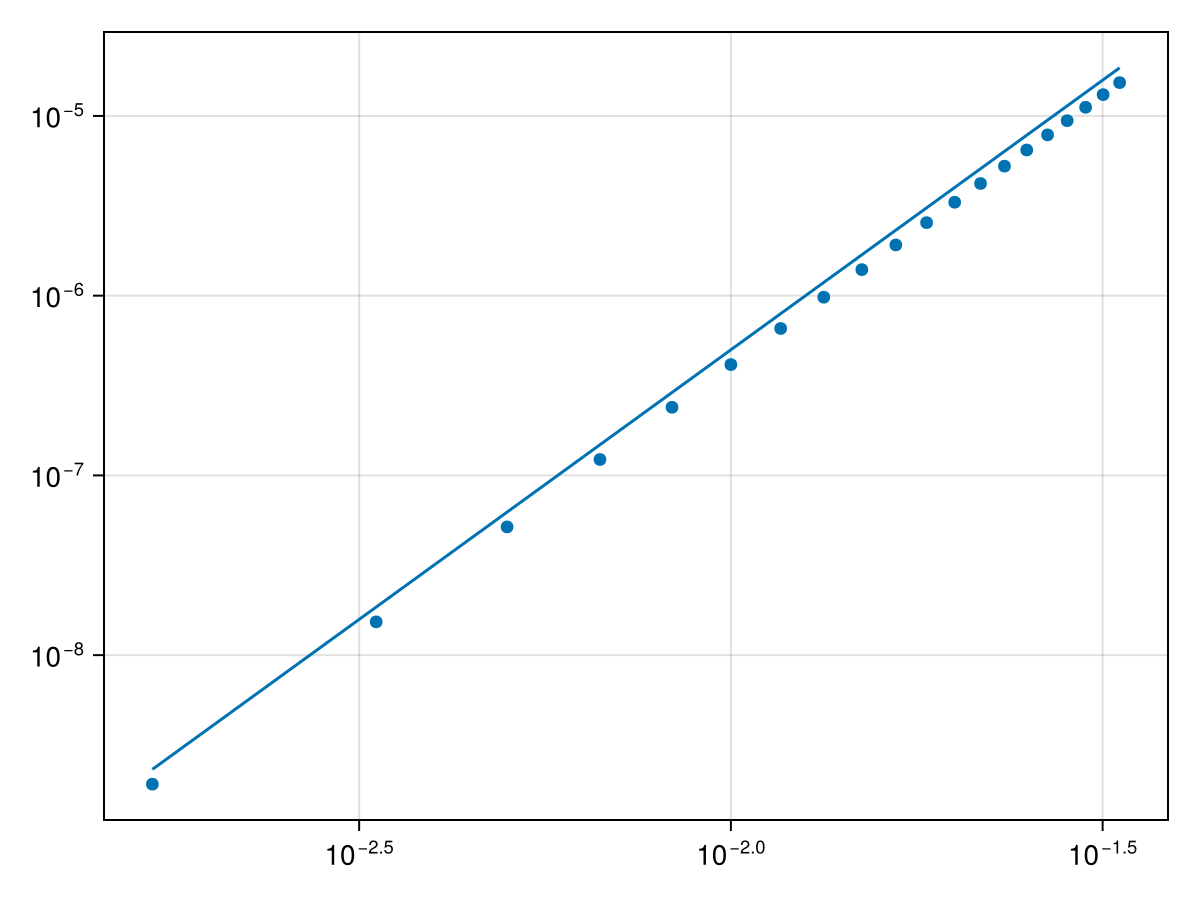

In [101]:
fig = Figure()
ax = Axis(fig[1,1]; xscale=log10, yscale=log10)

scatter!(ax, U0/3, synthetic_bs)
lines!(ax, U0/3, 0.5*(U0/3).^(3))
fig

In [84]:
function spatial_structure_V2(n, Q1, Q2, U0, L, grid)
    q = sqrt.(grid.Krsq)
    q_filter = q[Q1 .< q .< Q2]
    norm = 2 * U0^2 * L^2 / sum(q_filter.^(2-n))
    function P(q)
        return q^(-n) * (Q1 < q) * (q < Q2) * norm
    end

    return P
end

U0 = 5.0
P = spatial_structure_V2(6, 1/3, 176, U0, 2π, grid)

q = sqrt.(grid.Krsq)
phase = exp.(2im * π * rand(grid.nkr, grid.nl))
ψh = 2π*sqrt.(P.(q)/2) .* phase
uh = @. -1im * grid.l * ψh
vh = @.  1im * grid.kr * ψh
ζh = @. 1im * grid.kr * vh - 1im * grid.l * uh
ζ = irfft(ζh, grid.nx)
α = (sqrt.(sum(ζ.^2)/grid.nx/grid.ny * grid.Lx^2))
#sum((abs2.(uh) + abs2.(vh)) / grid.nx / grid.ny * grid.Lx^2)

0.013375715163910762


In [14]:
size(log(0.0005):0.1:log(0.3))

(64,)